# CNN and SVM Comparison

Use this notebook after running `python src/cnn.py`, `python src/cnn_improved.py`, `python src/svm.py`, `python src/svm_balanced.py`, `python src/svm_linear.py`, and `python src/svm_raw.py`. It compares `HOG + SVM (RBF)`, `HOG + SVM (RBF, balanced)`, `HOG + SVM (linear)`, `raw-pixel SVM`, the baseline CNN, and the upgraded CNN.

In [24]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"

BASELINE_HISTORY_PATH = DATA_DIR / "cnn_history.json"
BASELINE_RESULTS_PATH = DATA_DIR / "cnn_results.json"
BASELINE_MODEL_PATH = DATA_DIR / "best_cnn.pt"
BASELINE_TEST_PREDS_PATH = DATA_DIR / "cnn_test_predictions.npz"

IMPROVED_HISTORY_PATH = DATA_DIR / "cnn_improved_history.json"
IMPROVED_RESULTS_PATH = DATA_DIR / "cnn_improved_results.json"
IMPROVED_MODEL_PATH = DATA_DIR / "best_cnn_improved.pt"
IMPROVED_TEST_PREDS_PATH = DATA_DIR / "cnn_improved_test_predictions.npz"

SVM_RBF_RESULTS_PATH = DATA_DIR / "svm_results.json"
SVM_BALANCED_RESULTS_PATH = DATA_DIR / "svm_balanced_results.json"
SVM_LINEAR_RESULTS_PATH = DATA_DIR / "svm_linear_results.json"
SVM_RAW_RESULTS_PATH = DATA_DIR / "svm_raw_results.json"

LEGACY_HOG_RBF_TEST = {"top1": 0.0910, "top5": 0.2171}

plt.style.use("default")


def load_json(path):
    return json.loads(path.read_text())


def load_history(label, path):
    if not path.exists():
        return None
    return {"label": label, "path": path, "history": load_json(path)}


def cnn_metrics(label, history_path, results_path):
    history = load_json(history_path) if history_path.exists() else []
    results = load_json(results_path) if results_path.exists() else {}

    if "test" in results:
        return {"model": label, "split": "Test", "top1": results["test"]["top1"], "top5": results["test"]["top5"]}

    if history:
        best_val = max(history, key=lambda row: row["val_top1"])
        return {"model": label, "split": "Val", "top1": best_val["val_top1"], "top5": best_val["val_top5"]}

    return None


def svm_metrics(label, results_path, fallback=None):
    if results_path.exists():
        results = load_json(results_path)
        metric_block = results.get("test") or results.get("val")
        split = "Test" if results.get("test") else "Val"
        return {"model": label, "split": split, "top1": metric_block["top1"], "top5": metric_block["top5"]}

    if fallback is not None:
        return {"model": label, "split": "Test", "top1": fallback["top1"], "top5": fallback["top5"]}

    return None


def load_checkpoint_args(path):
    if not path.exists():
        return {}
    checkpoint = torch.load(path, map_location="cpu")
    return checkpoint.get("args", {})


def hyperparameter_rows():
    rows = []

    if SVM_RBF_RESULTS_PATH.exists():
        results = load_json(SVM_RBF_RESULTS_PATH)
        rows.append({
            "model": "HOG + SVM (RBF)",
            "hyperparameters": {
                "kernel": "rbf",
                **results.get("best_params", {}),
            },
        })

    if SVM_BALANCED_RESULTS_PATH.exists():
        results = load_json(SVM_BALANCED_RESULTS_PATH)
        rows.append({
            "model": "HOG + SVM (RBF, balanced)",
            "hyperparameters": {
                "kernel": "rbf",
                **results.get("best_params", {}),
            },
        })

    if SVM_LINEAR_RESULTS_PATH.exists():
        results = load_json(SVM_LINEAR_RESULTS_PATH)
        rows.append({
            "model": "HOG + SVM (linear)",
            "hyperparameters": {
                "kernel": "linear",
                **results.get("best_params", {}),
            },
        })

    if SVM_RAW_RESULTS_PATH.exists():
        results = load_json(SVM_RAW_RESULTS_PATH)
        rows.append({
            "model": "Raw pixels + SVM",
            "hyperparameters": {
                "kernel": "rbf",
                **results.get("preprocessing", {}),
                **results.get("best_params", {}),
            },
        })

    baseline_args = load_checkpoint_args(BASELINE_MODEL_PATH)
    if baseline_args:
        rows.append({
            "model": "Baseline CNN",
            "hyperparameters": {
                "backbone": "resnet18",
                "epochs": baseline_args.get("epochs"),
                "batch_size": baseline_args.get("batch_size"),
                "image_size": baseline_args.get("image_size"),
                "lr": baseline_args.get("lr"),
                "weight_decay": baseline_args.get("weight_decay"),
                "pretrained": baseline_args.get("pretrained"),
                "freeze_backbone": baseline_args.get("freeze_backbone"),
            },
        })

    improved_args = load_checkpoint_args(IMPROVED_MODEL_PATH)
    if improved_args:
        rows.append({
            "model": "Upgraded CNN",
            "hyperparameters": {
                "backbone": "resnet34",
                "epochs": improved_args.get("epochs"),
                "batch_size": improved_args.get("batch_size"),
                "image_size": improved_args.get("image_size"),
                "lr": improved_args.get("lr"),
                "weight_decay": improved_args.get("weight_decay"),
                "label_smoothing": improved_args.get("label_smoothing"),
                "pretrained": improved_args.get("pretrained"),
                "freeze_backbone": improved_args.get("freeze_backbone"),
            },
        })

    return rows


def format_hparams(hparams):
    return "\n".join(f"{k}={v}" for k, v in hparams.items() if v is not None)

## CNN Training Curves

In [25]:
histories = [
    load_history("Baseline CNN", BASELINE_HISTORY_PATH),
    load_history("Upgraded CNN", IMPROVED_HISTORY_PATH),
]
histories = [item for item in histories if item is not None]

if not histories:
    raise FileNotFoundError(
        "No CNN history files found. Run src/cnn.py and/or src/cnn_improved.py first."
    )

[item["label"] for item in histories]

['Baseline CNN', 'Upgraded CNN']

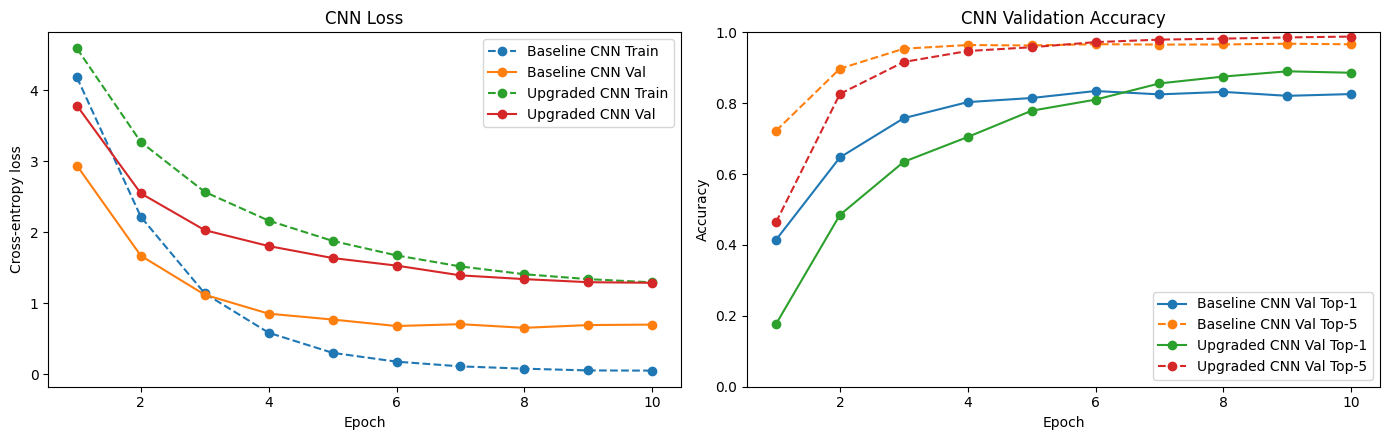

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for item in histories:
    label = item["label"]
    history = item["history"]
    epochs = [row["epoch"] for row in history]

    axes[0].plot(epochs, [row["train_loss"] for row in history], marker="o", linestyle="--", label=f"{label} Train")
    axes[0].plot(epochs, [row["val_loss"] for row in history], marker="o", label=f"{label} Val")

    axes[1].plot(epochs, [row["val_top1"] for row in history], marker="o", label=f"{label} Val Top-1")
    axes[1].plot(epochs, [row["val_top5"] for row in history], marker="o", linestyle="--", label=f"{label} Val Top-5")

axes[0].set_title("CNN Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()

axes[1].set_title("CNN Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()

## SVM and CNN Comparison

In [27]:
metrics = [
    svm_metrics("HOG + SVM (RBF)", SVM_RBF_RESULTS_PATH, fallback=LEGACY_HOG_RBF_TEST),
    svm_metrics("HOG + SVM (RBF, balanced)", SVM_BALANCED_RESULTS_PATH),
    svm_metrics("HOG + SVM (linear)", SVM_LINEAR_RESULTS_PATH),
    svm_metrics("Raw pixels + SVM", SVM_RAW_RESULTS_PATH),
    cnn_metrics("Baseline CNN", BASELINE_HISTORY_PATH, BASELINE_RESULTS_PATH),
    cnn_metrics("Upgraded CNN", IMPROVED_HISTORY_PATH, IMPROVED_RESULTS_PATH),
]
metrics = [row for row in metrics if row is not None]

if len(metrics) < 6:
    missing = []
    if not SVM_RBF_RESULTS_PATH.exists():
        missing.append("src/svm.py")
    if not SVM_BALANCED_RESULTS_PATH.exists():
        missing.append("src/svm_balanced.py")
    if not SVM_LINEAR_RESULTS_PATH.exists():
        missing.append("src/svm_linear.py")
    if not SVM_RAW_RESULTS_PATH.exists():
        missing.append("src/svm_raw.py")
    if not BASELINE_HISTORY_PATH.exists():
        missing.append("src/cnn.py")
    if not IMPROVED_HISTORY_PATH.exists():
        missing.append("src/cnn_improved.py")
    print("Missing artifacts from:", missing)

metrics

[{'model': 'HOG + SVM (RBF)',
  'split': 'Test',
  'top1': 0.09102141680395387,
  'top5': 0.2170510708401977},
 {'model': 'HOG + SVM (RBF, balanced)',
  'split': 'Test',
  'top1': 0.0914332784184514,
  'top5': 0.21622734761120263},
 {'model': 'HOG + SVM (linear)',
  'split': 'Test',
  'top1': 0.06795716639209226,
  'top5': 0.18080724876441515},
 {'model': 'Raw pixels + SVM',
  'split': 'Test',
  'top1': 0.03130148270181219,
  'top5': 0.08401976935749589},
 {'model': 'Baseline CNN',
  'split': 'Val',
  'top1': 0.8344316309719935,
  'top5': 0.9666392092257001},
 {'model': 'Upgraded CNN',
  'split': 'Val',
  'top1': 0.8900329489291599,
  'top5': 0.9855848434925865}]

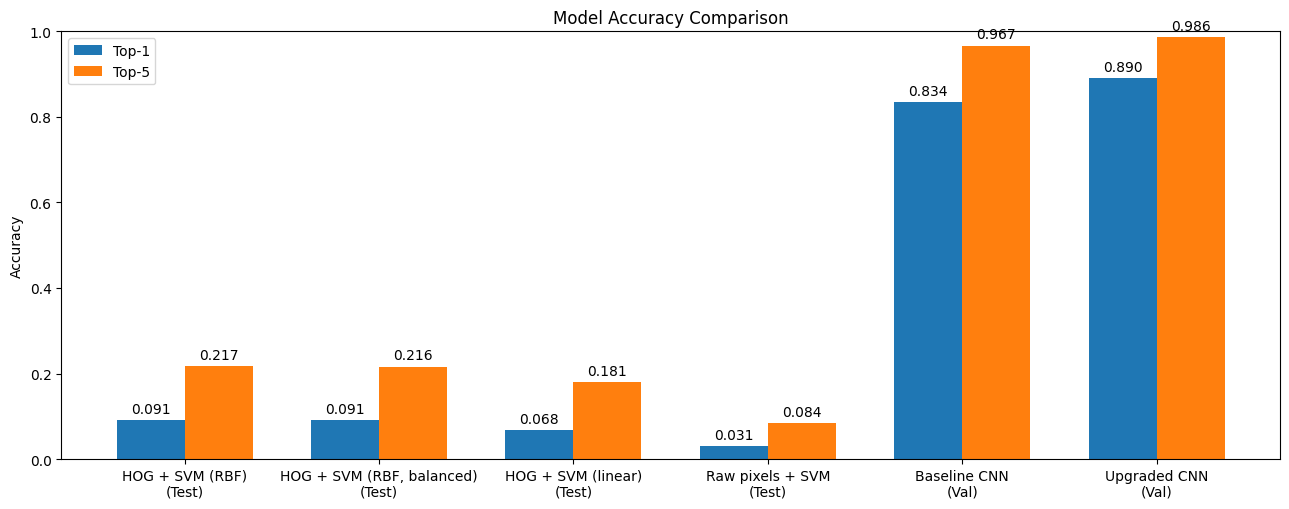

In [28]:
x = np.arange(len(metrics))
width = 0.35
labels = [f"{row['model']}\n({row['split']})" for row in metrics]

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.bar(x - width / 2, [row["top1"] for row in metrics], width, label="Top-1")
ax.bar(x + width / 2, [row["top5"] for row in metrics], width, label="Top-5")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Comparison")
ax.legend()

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()

## Hyperparameters

In [29]:
hparam_rows = hyperparameter_rows()

if not hparam_rows:
    print("No saved hyperparameters found yet.")
else:
    for row in hparam_rows:
        print(row["model"])
        print(format_hparams(row["hyperparameters"]))
        print()

HOG + SVM (RBF)
kernel=rbf
C=10.0
gamma=scale

HOG + SVM (RBF, balanced)
kernel=rbf
C=10.0
gamma=scale
class_weight=balanced

HOG + SVM (linear)
kernel=linear
C=0.1

Raw pixels + SVM
kernel=rbf
pca_components=256
C=10.0
gamma=scale

Baseline CNN
backbone=resnet18
epochs=10
batch_size=32
image_size=224
lr=0.0001
weight_decay=0.0001
pretrained=True
freeze_backbone=False

Upgraded CNN
backbone=resnet34
epochs=10
batch_size=32
image_size=224
lr=0.0003
weight_decay=0.0001
label_smoothing=0.1
pretrained=True
freeze_backbone=False



## HOG SVM Kernel and Weighting Comparison

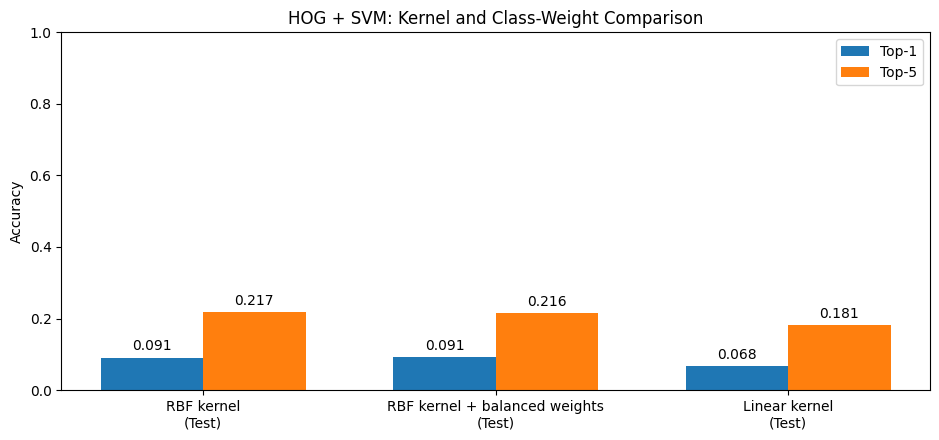

In [30]:
kernel_metrics = [
    svm_metrics("RBF kernel", SVM_RBF_RESULTS_PATH, fallback=LEGACY_HOG_RBF_TEST),
    svm_metrics("RBF kernel + balanced weights", SVM_BALANCED_RESULTS_PATH),
    svm_metrics("Linear kernel", SVM_LINEAR_RESULTS_PATH),
]
kernel_metrics = [row for row in kernel_metrics if row is not None]

if len(kernel_metrics) >= 2:
    x = np.arange(len(kernel_metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    ax.bar(x - width / 2, [row["top1"] for row in kernel_metrics], width, label="Top-1")
    ax.bar(x + width / 2, [row["top5"] for row in kernel_metrics], width, label="Top-5")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{row['model']}\n({row['split']})" for row in kernel_metrics])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_title("HOG + SVM: Kernel and Class-Weight Comparison")
    ax.legend()

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3)

    plt.tight_layout()
else:
    print("Run src/svm.py, src/svm_balanced.py, and src/svm_linear.py to compare HOG variants.")

## CNN Test Diagnostics

Run `python src/cnn.py --eval-test-only` and `python src/cnn_improved.py --eval-test-only` before using this section if you want both CNN prediction files.

In [31]:
prediction_files = [
    ("Baseline CNN", BASELINE_TEST_PREDS_PATH),
    ("Upgraded CNN", IMPROVED_TEST_PREDS_PATH),
]
available = [(label, path) for label, path in prediction_files if path.exists()]

if not available:
    print("No CNN test predictions found.")
else:
    fig, axes = plt.subplots(len(available), 1, figsize=(18, 4.5 * len(available)))
    axes = np.atleast_1d(axes)

    for ax, (label, path) in zip(axes, available):
        preds = np.load(path)
        y_true = preds["y_true"]
        y_pred = preds["y_pred"]

        classes = np.unique(y_true)
        per_class_acc = np.array([(y_pred[y_true == c] == c).mean() for c in classes])
        sort_idx = np.argsort(per_class_acc)

        ax.bar(np.arange(len(classes)), per_class_acc[sort_idx])
        ax.axhline(per_class_acc.mean(), color="red", linestyle="--", label=f"Mean: {per_class_acc.mean():.3f}")
        ax.set_title(f"{label} Per-Class Top-1 Accuracy")
        ax.set_xlabel("Class index, sorted by accuracy")
        ax.set_ylabel("Top-1 accuracy")
        ax.legend()

    plt.tight_layout()

No CNN test predictions found.
